# Arctic Energy Supply and Its Effects on Türkiye

## 1. Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import os

# colorblind-friendly palette
C_MEDBROWN = '#c99b38'
C_LIGHTBROWN = '#eddca5'
C_MEDTEAL = '#00b0be'
C_LIGHTTEAL = '#8fd7d7'
C_BASELINE = '#707070'

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'legend.fontsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'figure.dpi': 150, 'savefig.dpi': 600
})
os.makedirs('./report/Figures', exist_ok=True)

## 2. Türkiye's Energy Trap

### Load Price Data

We need to find out baseline price to create a price model. I decided to take the average of 2025 as the baseline. 

In [18]:
# Load price data
oil_price_df = pd.read_csv('./data/POILBREUSDM.csv')
oil_price_df['observation_date'] = pd.to_datetime(oil_price_df['observation_date'])

gas_price_df = pd.read_csv('./data/PNGASEUUSDM.csv')
gas_price_df['observation_date'] = pd.to_datetime(gas_price_df['observation_date'])

# 2025 mean will be our baseline
oil_2025 = oil_price_df[oil_price_df['observation_date'].dt.year == 2025]
gas_2025 = gas_price_df[gas_price_df['observation_date'].dt.year == 2025]
baseline_oil_price = oil_2025['POILBREUSDM'].mean()
baseline_gas_price = gas_2025['PNGASEUUSDM'].mean()
oil_std = oil_2025['POILBREUSDM'].std()
gas_std = gas_2025['PNGASEUUSDM'].std()
print(f"Baseline Oil: ${baseline_oil_price:.2f}/bbl, Gas: ${baseline_gas_price:.2f}/MMBtu")

Baseline Oil: $68.32/bbl, Gas: $11.91/MMBtu


### Load Current Account Balance Data for Turkiye

To show the relationship between CA and energy prices we need this data.

In [19]:
# Load CA balance data
CA_df = pd.read_excel('./data/turkiye_CA_balance.xlsx', usecols=[0,1,2])[:278]
CA_df['Date'] = pd.to_datetime(CA_df['Date'])
CA_df = CA_df.rename(columns={'Date':'date','TP_HARICCARIACIK_K1':'total_ca','TP_HARICCARIACIK_K10':'core_ca'})

oil_for_ca = oil_price_df.rename(columns={'observation_date':'date','POILBREUSDM':'oil_price'})
combined_df = pd.merge(CA_df, oil_for_ca[['date','oil_price']], on='date', how='inner')
combined_df['total_ca_smooth'] = combined_df['total_ca'].rolling(12).mean()
combined_df['core_ca_smooth'] = combined_df['core_ca'].rolling(12).mean()
combined_df['oil_smooth'] = combined_df['oil_price'].rolling(12).mean()
combined_df = combined_df.dropna()
print("CA balance data loaded and merged.")

CA balance data loaded and merged.


c:\Users\sahin\OneDrive\Belgeler\programming\economy-thesis\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


### The Relationship Between CA and Energy Prices

Let's show the inverse relationship between oil prices and Türkiye's current account to demonstrate how they are related.

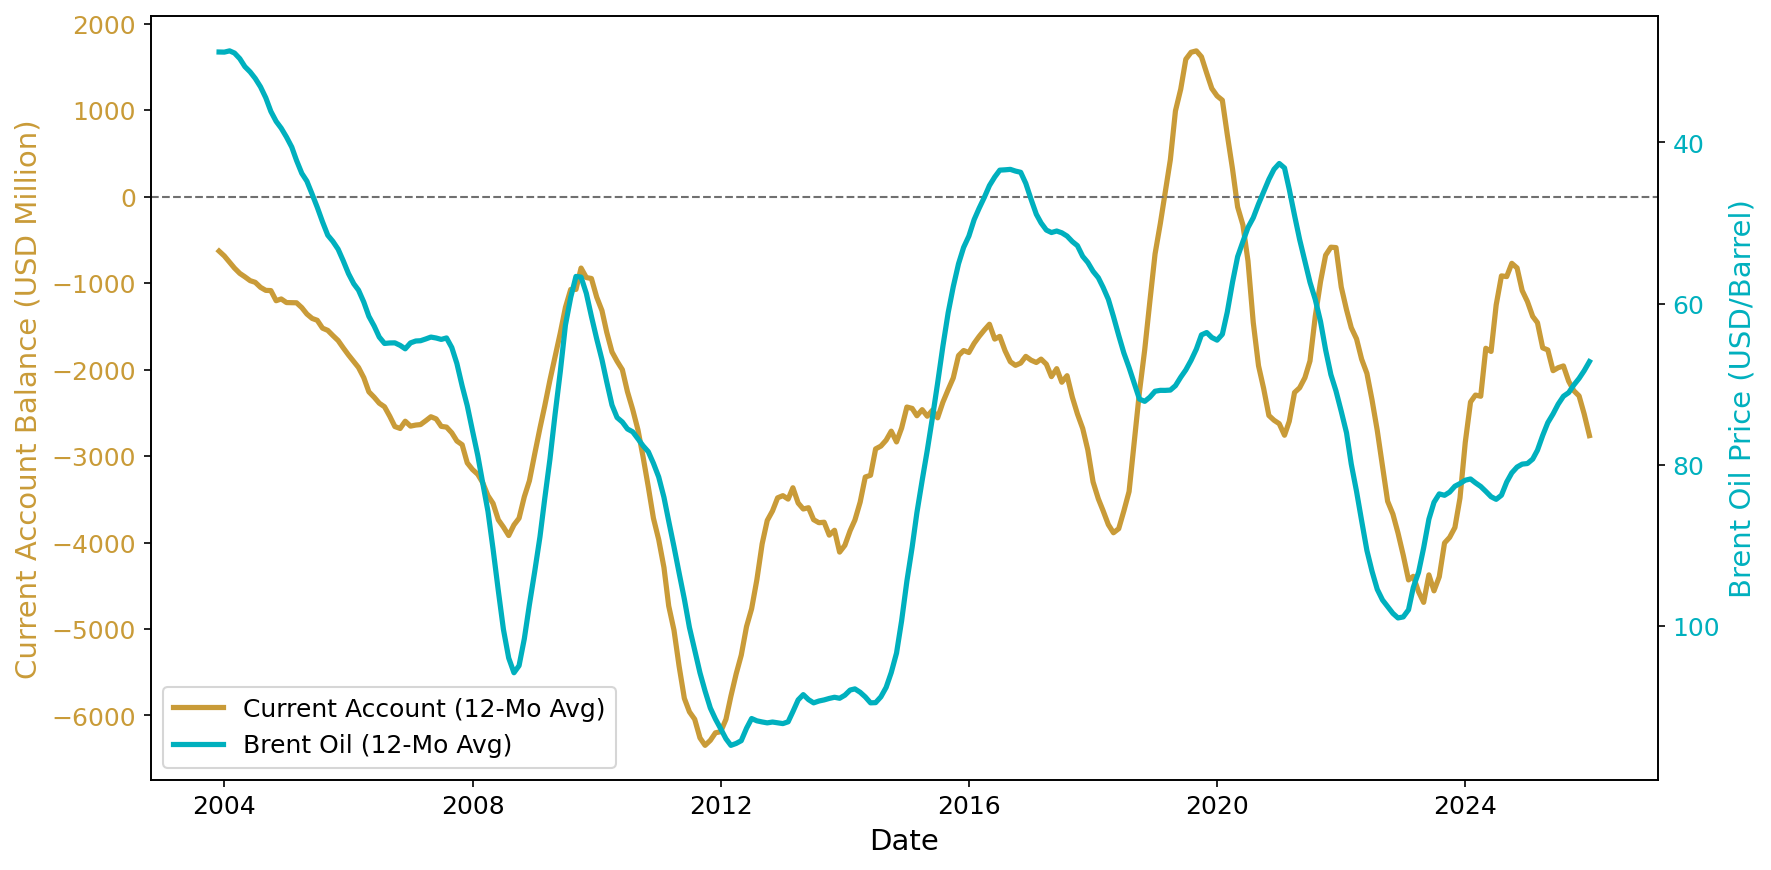

In [20]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date')
ax1.set_ylabel('Current Account Balance (USD Million)', color=C_MEDBROWN)
ax1.plot(combined_df['date'], combined_df['total_ca_smooth'], color=C_MEDBROWN, linewidth=2.5, label='Current Account (12-Mo Avg)')
ax1.tick_params(axis='y', labelcolor=C_MEDBROWN)
ax1.axhline(0, color=C_BASELINE, linestyle='--', linewidth=1)

ax2 = ax1.twinx()
ax2.set_ylabel('Brent Oil Price (USD/Barrel)', color=C_MEDTEAL)
ax2.plot(combined_df['date'], combined_df['oil_smooth'], color=C_MEDTEAL, linewidth=2.5, label='Brent Oil (12-Mo Avg)')
ax2.tick_params(axis='y', labelcolor=C_MEDTEAL, )
ax2.invert_yaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='lower left', frameon=True)
# plt.title("Türkiye's Energy Trap: Oil Prices vs. Current Account Balance\n(12-Month Moving Average)", fontsize=15, pad=10)
fig.tight_layout()
plt.savefig('./report/Figures/energy_trap.png')
plt.show()

### Current Account With and Without Energy
We saw oil prices have negative realtionship between CA. To understand this better let's decompose Türkiye's CA into total and core (excl. energy & gold).

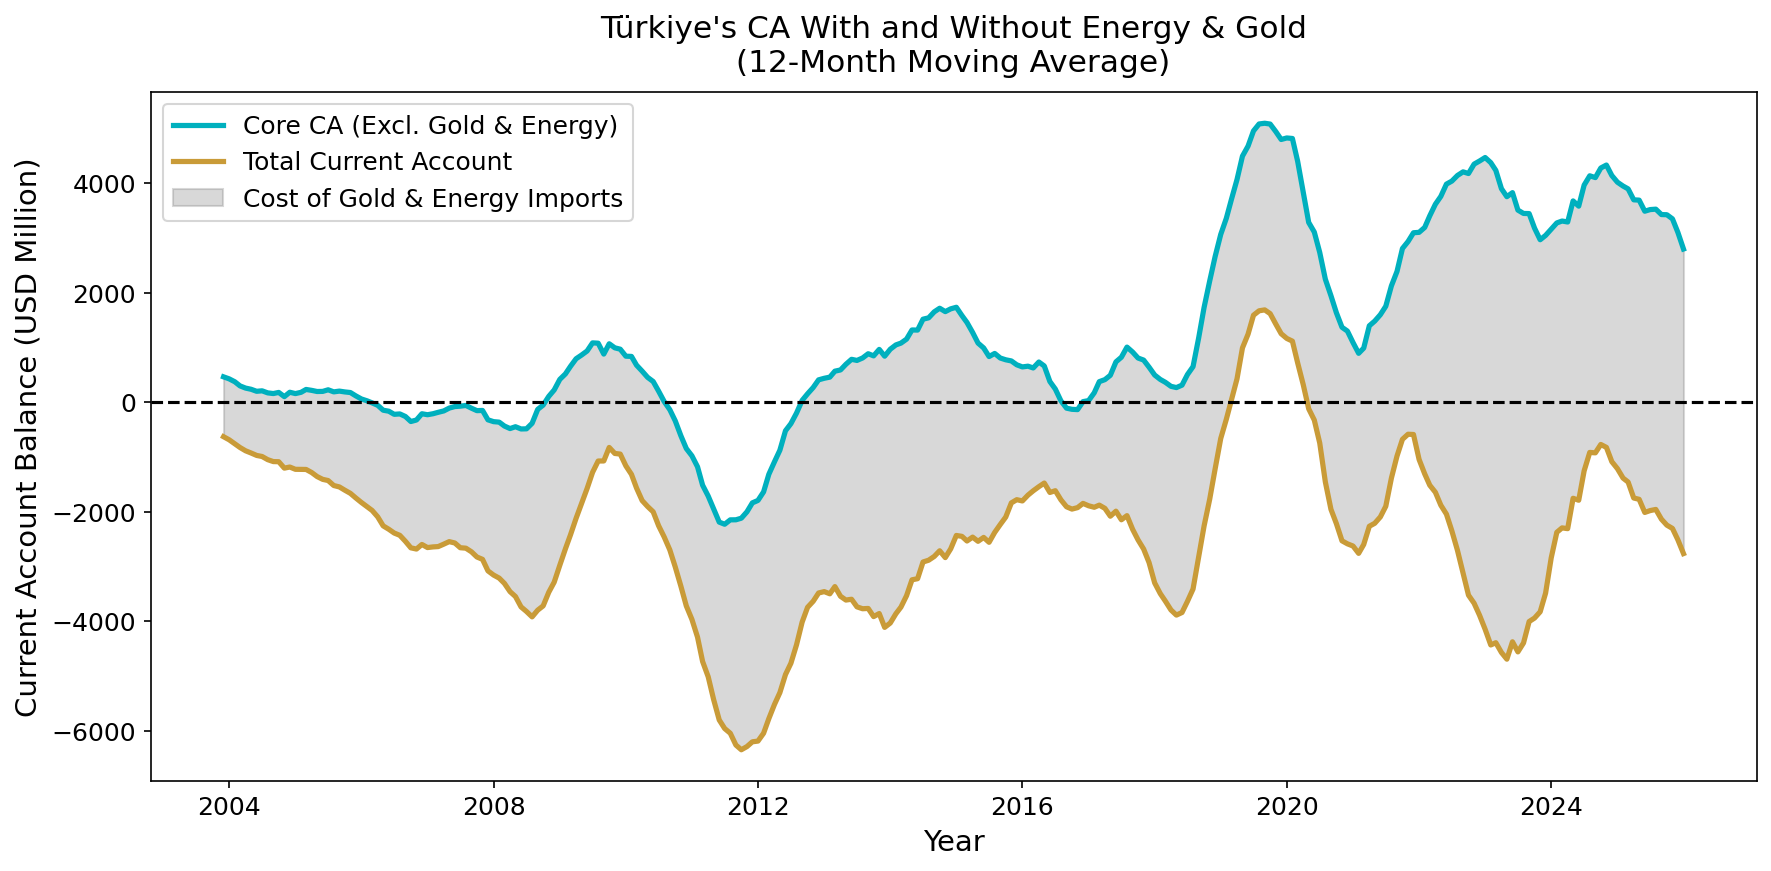

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(combined_df['date'], combined_df['core_ca_smooth'], color=C_MEDTEAL, linewidth=2.5, label='Core CA (Excl. Gold & Energy)')
ax.plot(combined_df['date'], combined_df['total_ca_smooth'], color=C_MEDBROWN, linewidth=2.5, label='Total Current Account')
ax.fill_between(combined_df['date'], combined_df['total_ca_smooth'], combined_df['core_ca_smooth'], color='gray', alpha=0.3, label='Cost of Gold & Energy Imports')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Current Account Balance (USD Million)')
plt.title("Türkiye's CA With and Without Energy & Gold\n(12-Month Moving Average)", fontsize=15, pad=10)
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.savefig('./report/Figures/ca_decomposition.png')
plt.show()

## 3. Oil & Gas Trajectories

### Load Consumption and Production Data

* We multiply Oil Consumption/Production data with 365 to count yearly barrels and divide it by 1000 to transform it from thousands since the file values are 'thosuand barrels daily'
* We multiply Gas Consumption/Production data with 365 to count yearly amount

In [22]:
ei_file = './data/EI-Stats-Review-ALL-data.xlsx'

def extract_timeseries(file, sheet, row_name):
    df = pd.read_excel(file, sheet_name=sheet, header=2)
    row = df[df.iloc[:, 0] == row_name]
    if sheet in ['Oil Consumption - barrels', 'Gas Consumption - Bcf', 'Oil Production - barrels']:
        series = row.iloc[0, 1:61].astype(float)
    elif sheet in ['Gas Production - bcf']:
        series = row.iloc[0, 1:56].astype(float)
    series.index = series.index.astype(int)
    return series.dropna()

world_oil_cons = extract_timeseries(ei_file, 'Oil Consumption - barrels', 'Total World') * 0.365
world_gas_cons = extract_timeseries(ei_file, 'Gas Consumption - Bcf', 'Total World') * 365
world_oil_prod = extract_timeseries(ei_file, 'Oil Production - barrels', 'Total World') * 0.365
world_gas_prod = extract_timeseries(ei_file, 'Gas Production - bcf', 'Total World') * 365
turkiye_oil_cons = extract_timeseries(ei_file, 'Oil Consumption - barrels', 'Turkey') * 0.365
turkiye_gas_cons = extract_timeseries(ei_file, 'Gas Consumption - Bcf', 'Turkey') * 365
print("Energy data loaded.")

Energy data loaded.


### Linear Regression Models for Trajectories
* We need to predict the consumption and production for both oil and gas to understand the effect of possible energy price drop. 
* In this section I will create projections with the baselines we calculated based on linear regression of 1970–2024 data.
* I also show the slope, intercept and R^2 values from our models

In [23]:
FORECAST_HORIZON = 27  # 2024 to 2050 inclusive

def forecast_linear(series, train_start=1970, horizon=FORECAST_HORIZON, label=None):
    train = series.loc[train_start:]
    X = np.array(train.index).reshape(-1, 1)
    model = LinearRegression().fit(X, train.values)
    r2 = model.score(X, train.values)
    last = train.index.max()
    X_fut = np.arange(last, last + horizon).reshape(-1, 1)
    if label:
        sign = "+" if model.intercept_ >= 0 else "-"
        print(f"  {label:30s}:  Y = {model.coef_[0]:.4f}·t {sign} {abs(model.intercept_):.2f}   (R² = {r2:.4f})")
    return pd.Series(model.predict(X_fut), index=X_fut.flatten().astype(int))

print("Fitted baseline equations (training data: 1970–2024):\n")
fc_w_oil_c = forecast_linear(world_oil_cons, label="World Oil Consumption")
fc_w_oil_p = forecast_linear(world_oil_prod, label="World Oil Production")
fc_w_gas_c = forecast_linear(world_gas_cons, label="World Gas Consumption")
fc_w_gas_p = forecast_linear(world_gas_prod, label="World Gas Production")
fc_t_oil_c = forecast_linear(turkiye_oil_cons, label="Türkiye Oil Consumption")
fc_t_gas_c = forecast_linear(turkiye_gas_cons, label="Türkiye Gas Consumption")
print(f"\nProjection range: {fc_w_oil_c.index[0]}–{fc_w_oil_c.index[-1]}")

Fitted baseline equations (training data: 1970–2024):

  World Oil Consumption         :  Y = 346.5039·t - 664709.99   (R² = 0.9686)
  World Oil Production          :  Y = 304.7156·t - 581890.51   (R² = 0.9425)
  World Gas Consumption         :  Y = 2088.2122·t - 4086135.84   (R² = 0.9835)
  World Gas Production          :  Y = 2100.1964·t - 4109642.52   (R² = 0.9819)
  Türkiye Oil Consumption       :  Y = 5.9818·t - 11732.02   (R² = 0.9464)
  Türkiye Gas Consumption       :  Y = 41.0016·t - 81229.45   (R² = 0.8814)

Projection range: 2024–2050


### Global Consumption and Production Trajectories

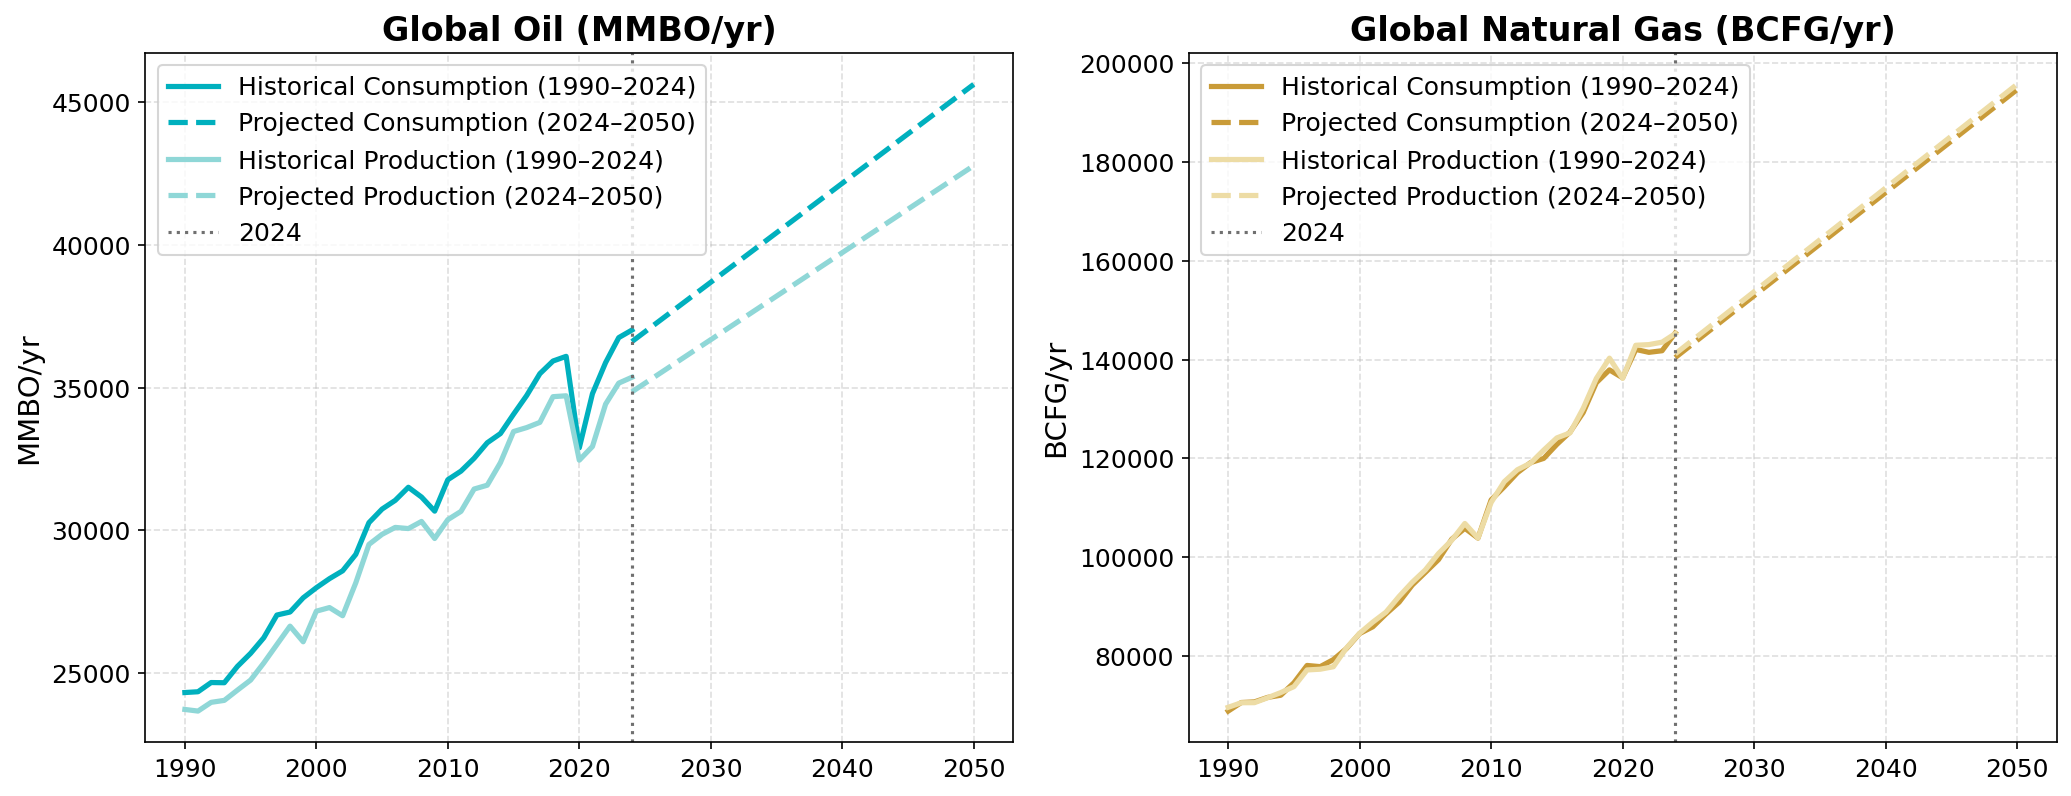

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(world_oil_cons.loc[1990:], label='Historical Consumption (1990–2024)', color=C_MEDTEAL, linewidth=2.5)
ax1.plot(fc_w_oil_c, label='Projected Consumption (2024–2050)', color=C_MEDTEAL, linestyle='--', linewidth=2.5)
ax1.plot(world_oil_prod.loc[1990:], label='Historical Production (1990–2024)', color=C_LIGHTTEAL, linewidth=2.5)
ax1.plot(fc_w_oil_p, label='Projected Production (2024–2050)', color=C_LIGHTTEAL, linestyle='--', linewidth=2.5)
ax1.axvline(x=2024, color=C_BASELINE, linestyle=':', label='2024')
ax1.set_title('Global Oil (MMBO/yr)', fontweight='bold')
ax1.set_ylabel('MMBO/yr'); ax1.legend(); ax1.grid(alpha=0.4, linestyle='--')

ax2.plot(world_gas_cons.loc[1990:], label='Historical Consumption (1990–2024)', color=C_MEDBROWN, linewidth=2.5)
ax2.plot(fc_w_gas_c, label='Projected Consumption (2024–2050)', color=C_MEDBROWN, linestyle='--', linewidth=2.5)
ax2.plot(world_gas_prod.loc[1990:], label='Historical Production (1990–2024)', color=C_LIGHTBROWN, linewidth=2.5)
ax2.plot(fc_w_gas_p, label='Projected Production (2024–2050)', color=C_LIGHTBROWN, linestyle='--', linewidth=2.5)
ax2.axvline(x=2024, color=C_BASELINE, linestyle=':', label='2024')
ax2.set_title('Global Natural Gas (BCFG/yr)', fontweight='bold')
ax2.set_ylabel('BCFG/yr'); ax2.legend(); ax2.grid(alpha=0.4, linestyle='--')

plt.tight_layout()
plt.savefig('./report/Figures/global_trajectory.png')
plt.show()

## Türkiye's Consumption Trajectory
I decided to check only the consumption for Türkiye since production wouldn't really mean anything as Türkiye does not export/produce energy significantly.

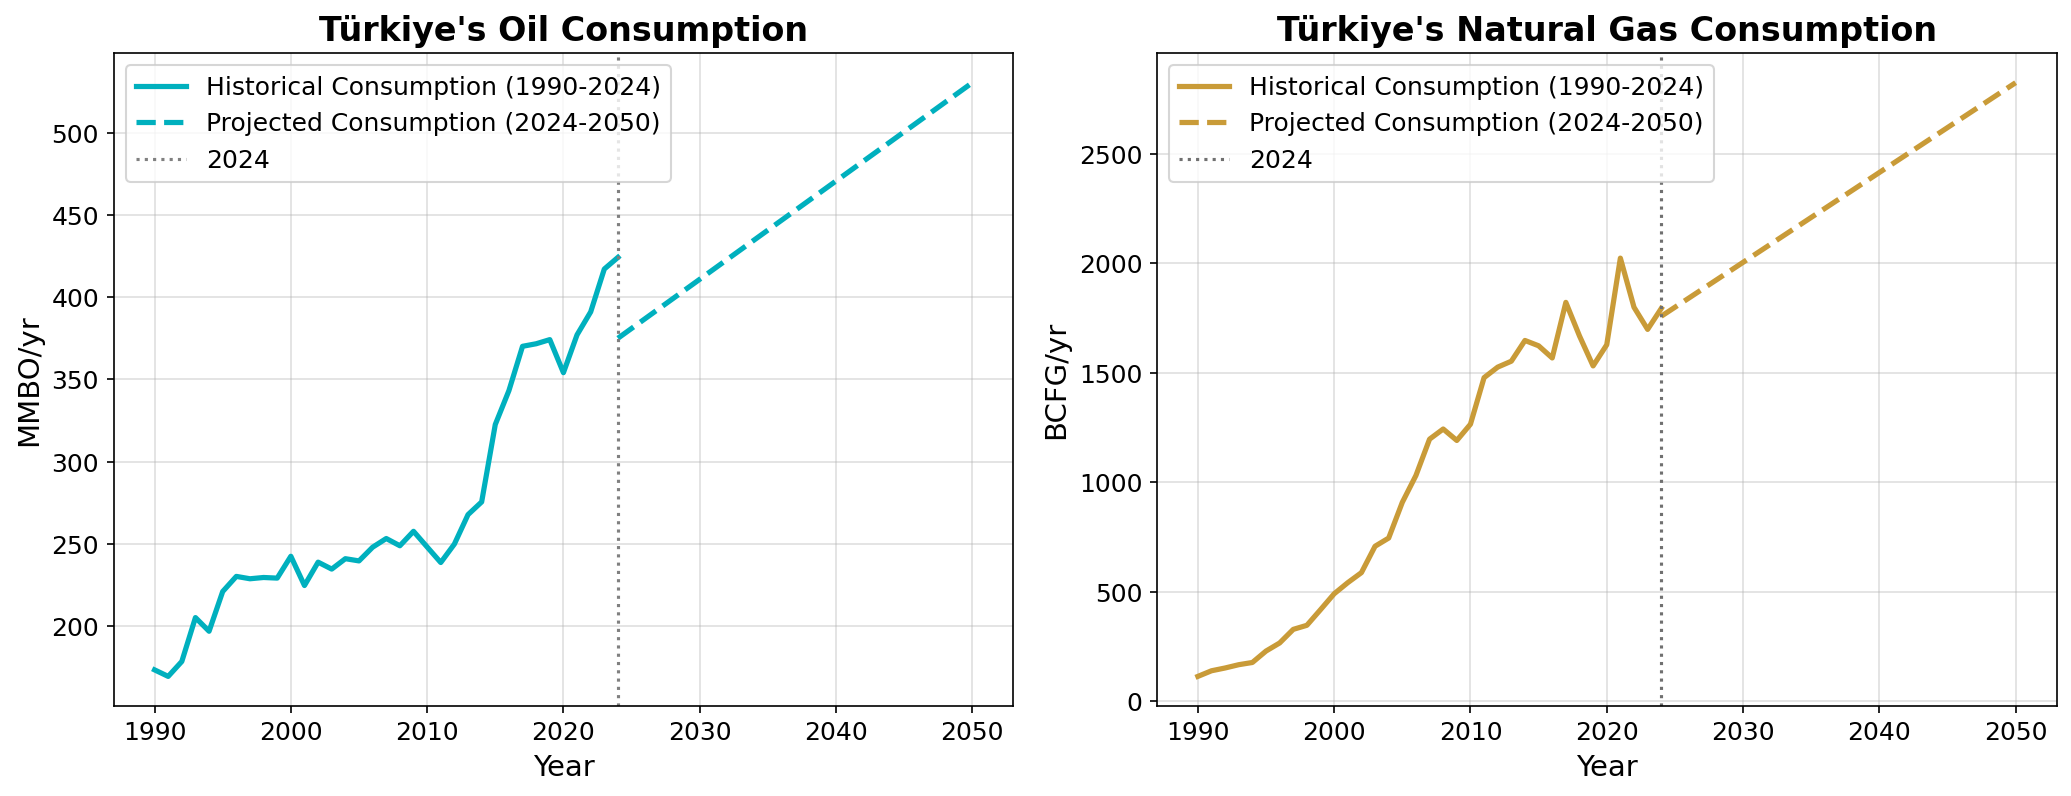

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
ax1.plot(turkiye_oil_cons.loc[1990:], label='Historical Consumption (1990-2024)', color=C_MEDTEAL, linewidth=2.5)
ax1.plot(fc_t_oil_c, label='Projected Consumption (2024-2050)', color=C_MEDTEAL, linestyle='--', linewidth=2.5)
ax1.axvline(x=2024, color='gray', linestyle=':', label='2024')
ax1.set_title("Türkiye's Oil Consumption", fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('MMBO/yr'); ax1.legend(); ax1.grid(alpha=0.4)

ax2.plot(turkiye_gas_cons.loc[1990:], label='Historical Consumption (1990-2024)', color=C_MEDBROWN, linewidth=2.5)
ax2.plot(fc_t_gas_c, label='Projected Consumption (2024-2050)', color=C_MEDBROWN, linestyle='--', linewidth=2.5)
ax2.axvline(x=2024, color=C_BASELINE, linestyle=':', label='2024')
ax2.set_title("Türkiye's Natural Gas Consumption", fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('BCFG/yr'); ax2.legend(); ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('./report/Figures/turkiye_forecast.png')
plt.show()

## 6. CARA 2008 Arctic Resource Data & Table

### Load and display the province-level Arctic resource estimates.
I assigned each province to a country but didn't use this in my report since I am not sure if I assigned them correctly.

In [26]:
cara_data = [
    ["WSB","West Siberian Basin","Russia",3659.88,651498.56,20328.69,132571.66],
    ["AA","Arctic Alaska","USA",29960.94,221397.60,5904.97,72765.52],
    ["EBB","East Barents Basin","Russia",7406.49,317557.97,1422.28,61755.10],
    ["EGR","East Greenland Rift Basins","Greenland",8902.13,86180.06,8121.57,31387.04],
    ["YK","Yenisey-Khatanga Basin","Russia",5583.74,99964.26,2675.15,24919.61],
    ["AM","Amerasia Basin","International/Deep Water",9723.58,56891.21,541.69,19747.14],
    ["WGEC","West Greenland-East Canada","Greenland/Canada",7274.40,51818.16,1152.59,17063.35],
    ["LSS","Laptev Sea Shelf","Russia",3115.57,32562.84,867.16,9409.87],
    ["NM","Norwegian Margin","Norway",1437.29,32281.01,504.73,7322.19],
    ["BP","Barents Platform","Norway",2055.51,26218.67,278.71,6704.00],
    ["EB","Eurasia Basin","International/Deep Water",1342.15,19475.43,520.26,5108.31],
    ["NKB","North Kara Basins","Russia",1807.26,14973.58,390.22,4693.07],
    ["TPB","Timan-Pechora Basin","Russia",1667.21,9062.59,202.80,3380.44],
    ["NGS","North Greenland Sheared Margin","Greenland",1349.80,10207.24,273.09,3324.09],
    ["LM","Lomonosov-Makarov","International/Deep Water",1106.78,7156.25,191.55,2491.04],
    ["SB","Sverdrup Basin","Canada",851.11,8596.36,191.20,2475.04],
    ["LA","Lena-Anabar Basin","Russia",1912.89,2106.75,56.41,2320.43],
    ["NCWF","N. Chukchi-Wrangel","Russia",85.99,6065.76,106.57,1203.52],
    ["VLK","Vilkitskii Basin","Russia",98.03,5741.87,101.63,1156.63],
    ["NWLS","NW Laptev Sea Shelf","Russia",172.24,4488.12,119.63,1039.90],
    ["LV","Lena-Vilyui Basin","Russia",376.86,1335.20,35.66,635.06],
    ["ZB","Zyryanka Basin","Russia",47.82,1505.99,40.14,338.95],
    ["ESS","East Siberian Sea","Russia",19.73,618.83,10.91,133.78],
    ["HB","Hope Basin","USA",2.47,648.17,11.37,121.87],
    ["NWC","NW Canada Interior","Canada",23.34,305.34,15.24,89.47],
]

df_cara = pd.DataFrame(cara_data, columns=["Code","Province","Country","Oil (MMBO)","Gas (BCFG)","NGL (MMBNGL)","BOE (MMBOE)"])

country_grp = df_cara.groupby('Country')[['Oil (MMBO)','Gas (BCFG)','NGL (MMBNGL)','BOE (MMBOE)']].sum()
country_grp = country_grp.sort_values('BOE (MMBOE)', ascending=False)
print("CARA 2008 Arctic Resources by Country (needs confirmation for the country-province matching):")
print(country_grp.round(0).to_string())

CARA 2008 Arctic Resources by Country (needs confirmation for the country-province matching):
                          Oil (MMBO)  Gas (BCFG)  NGL (MMBNGL)  BOE (MMBOE)
Country                                                                    
Russia                       25954.0   1147482.0       26357.0     243558.0
USA                          29963.0    222046.0        5916.0      72887.0
Greenland                    10252.0     96387.0        8395.0      34711.0
International/Deep Water     12173.0     83523.0        1254.0      27346.0
Greenland/Canada              7274.0     51818.0        1153.0      17063.0
Norway                        3493.0     58500.0         783.0      14026.0
Canada                         874.0      8902.0         206.0       2565.0


## 7. Arctic Supply Integration
Shows how Arctic oil and gas are gradually added to global production under three extraction rate scenarios.

In [27]:
# Base constants
arctic_oil = 90_000     # MMBO
arctic_gas = 1_669_000  # BCFG
years = len(fc_w_oil_p) # 27 years total (2024-2050)
# We want the ramp to only cover 2025 to 2050 (26 years)
# The ramp will be 0 in 2025, and hit its maximum in 2050
ramp_years = years - 1  
ramp = np.linspace(0, 1, ramp_years)
norm_ramp = ramp / ramp.sum()
# Define the exact scenarios
scenarios = {
    'Conservative (5%)': {'rate': 0.05, 'ls': ':'},
    'Moderate (10%)':    {'rate': 0.10, 'ls': '--'},
    'Optimistic (20%)':  {'rate': 0.20, 'ls': '-'}
}
arctic_additions = {}
print(f"{'':42s} {'2030':>10s} {'2040':>10s} {'2050':>10s}")
print("-" * 65)
for label, config in scenarios.items():
    rate = config['rate']
    
    # Create empty arrays of 0 for all 27 years
    oil_add_vals = np.zeros(years)
    gas_add_vals = np.zeros(years)
    
    # Fill from 2025 onward (index 1 to the end). 
    # 2024 remains 0. 2025 becomes 0. 2026 becomes > 0.
    oil_add_vals[1:] = arctic_oil * rate * norm_ramp
    gas_add_vals[1:] = arctic_gas * rate * norm_ramp
    
    # Bind to Pandas Series
    oil_add = pd.Series(oil_add_vals, index=fc_w_oil_p.index)
    gas_add = pd.Series(gas_add_vals, index=fc_w_oil_p.index)
    
    # Store for the plotting cell
    arctic_additions[label] = {
        'oil': oil_add,
        'gas': gas_add,
        'ls': config['ls']
    }
    # Print exact years
    print(f"  {label:28s} Oil (MMBO/yr):  {oil_add.loc[2030]:>8.1f}  {oil_add.loc[2040]:>8.1f}  {oil_add.loc[2050]:>8.1f}")
    print(f"  {'':28s} Gas (BCFG/yr):  {gas_add.loc[2030]:>8.1f}  {gas_add.loc[2040]:>8.1f}  {gas_add.loc[2050]:>8.1f}")
    
    # Print cumulative sums
    print(f"  {'':28s} Oil cum total:  {oil_add.loc[:2030].sum():>8.1f}  {oil_add.loc[:2040].sum():>8.1f}  {oil_add.sum():>8.1f}")
    print(f"  {'':28s} Gas cum total:  {gas_add.loc[:2030].sum():>8.1f}  {gas_add.loc[:2040].sum():>8.1f}  {gas_add.sum():>8.1f}")
    # Print percentages
    pct_oil_50 = (oil_add.loc[2050] / fc_w_oil_p.loc[2050]) * 100
    pct_gas_50 = (gas_add.loc[2050] / fc_w_gas_p.loc[2050]) * 100
    print(f"  {'':28s} % of 2050 prod: Oil {pct_oil_50:.2f}%, Gas {pct_gas_50:.2f}%")
    print()

                                                 2030       2040       2050
-----------------------------------------------------------------
  Conservative (5%)            Oil (MMBO/yr):      69.2     207.7     346.2
                               Gas (BCFG/yr):    1283.8    3851.5    6419.2
                               Oil cum total:     207.7    1661.5    4500.0
                               Gas cum total:    3851.5   30812.3   83450.0
                               % of 2050 prod: Oil 0.81%, Gas 3.28%

  Moderate (10%)               Oil (MMBO/yr):     138.5     415.4     692.3
                               Gas (BCFG/yr):    2567.7    7703.1   12838.5
                               Oil cum total:     415.4    3323.1    9000.0
                               Gas cum total:    7703.1   61624.6  166900.0
                               % of 2050 prod: Oil 1.62%, Gas 6.56%

  Optimistic (20%)             Oil (MMBO/yr):     276.9     830.8    1384.6
                               Gas (

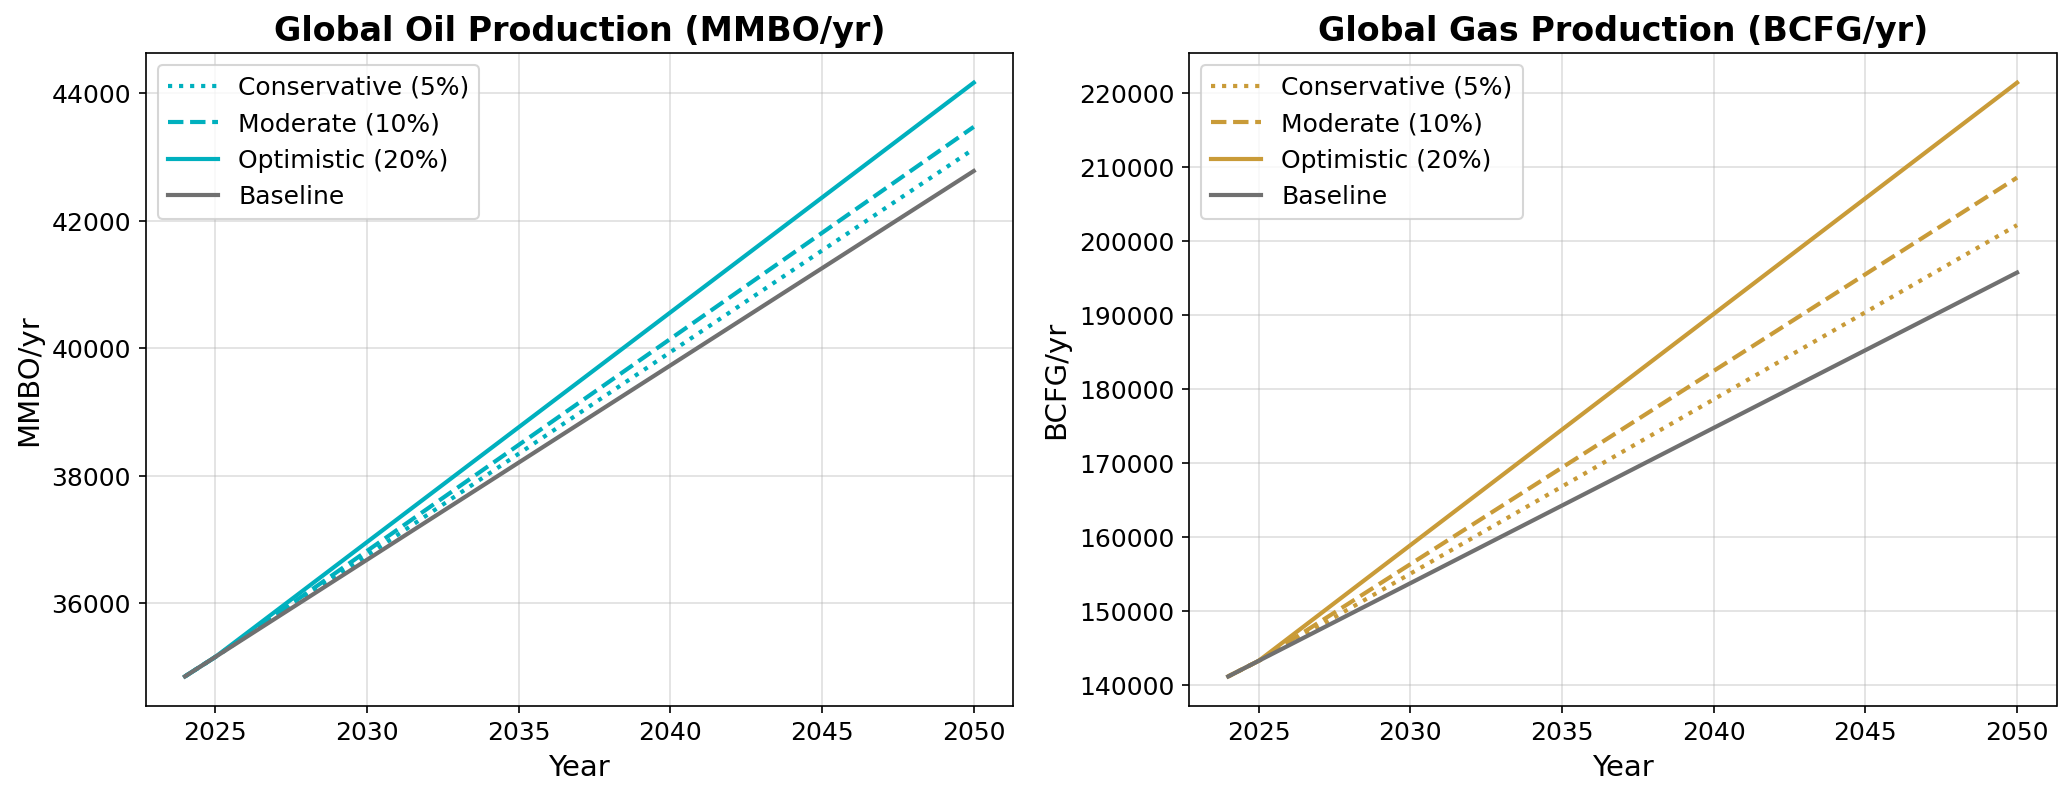

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Force ticks exactly on 2025, 2030, 2035, 2040, 2045, 2050
x_ticks = np.arange(2025, 2051, 5)

# --- Left Plot: Oil Production ---
for label, data in arctic_additions.items():
    enhanced = fc_w_oil_p + data['oil']
    ax1.plot(enhanced, label=label, color=C_MEDTEAL, linestyle=data['ls'], linewidth=2)
    
ax1.plot(fc_w_oil_p, label='Baseline', color=C_BASELINE, linestyle='-', linewidth=2)
ax1.set_title('Global Oil Production (MMBO/yr)', fontweight='bold')
ax1.set_ylabel('MMBO/yr')
ax1.set_xlabel('Year')
ax1.legend()
ax1.grid(alpha=0.4, linestyle='-')
ax1.set_xticks(x_ticks)

# --- Right Plot: Gas Production ---
for label, data in arctic_additions.items():
    enhanced = fc_w_gas_p + data['gas']
    ax2.plot(enhanced, label=label, color=C_MEDBROWN, linestyle=data['ls'], linewidth=2)
    
ax2.plot(fc_w_gas_p, label='Baseline', color=C_BASELINE, linestyle='-', linewidth=2)
ax2.set_title('Global Gas Production (BCFG/yr)', fontweight='bold')
ax2.set_ylabel('BCFG/yr')
ax2.set_xlabel('Year')
ax2.legend()
ax2.grid(alpha=0.4, linestyle='-')
ax2.set_xticks(x_ticks)

plt.tight_layout()
plt.savefig('./report/Figures/arctic_supply.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Price Depression Dynamics with 95% CI
Simulated price trajectories for the moderate scenario with confidence bands.

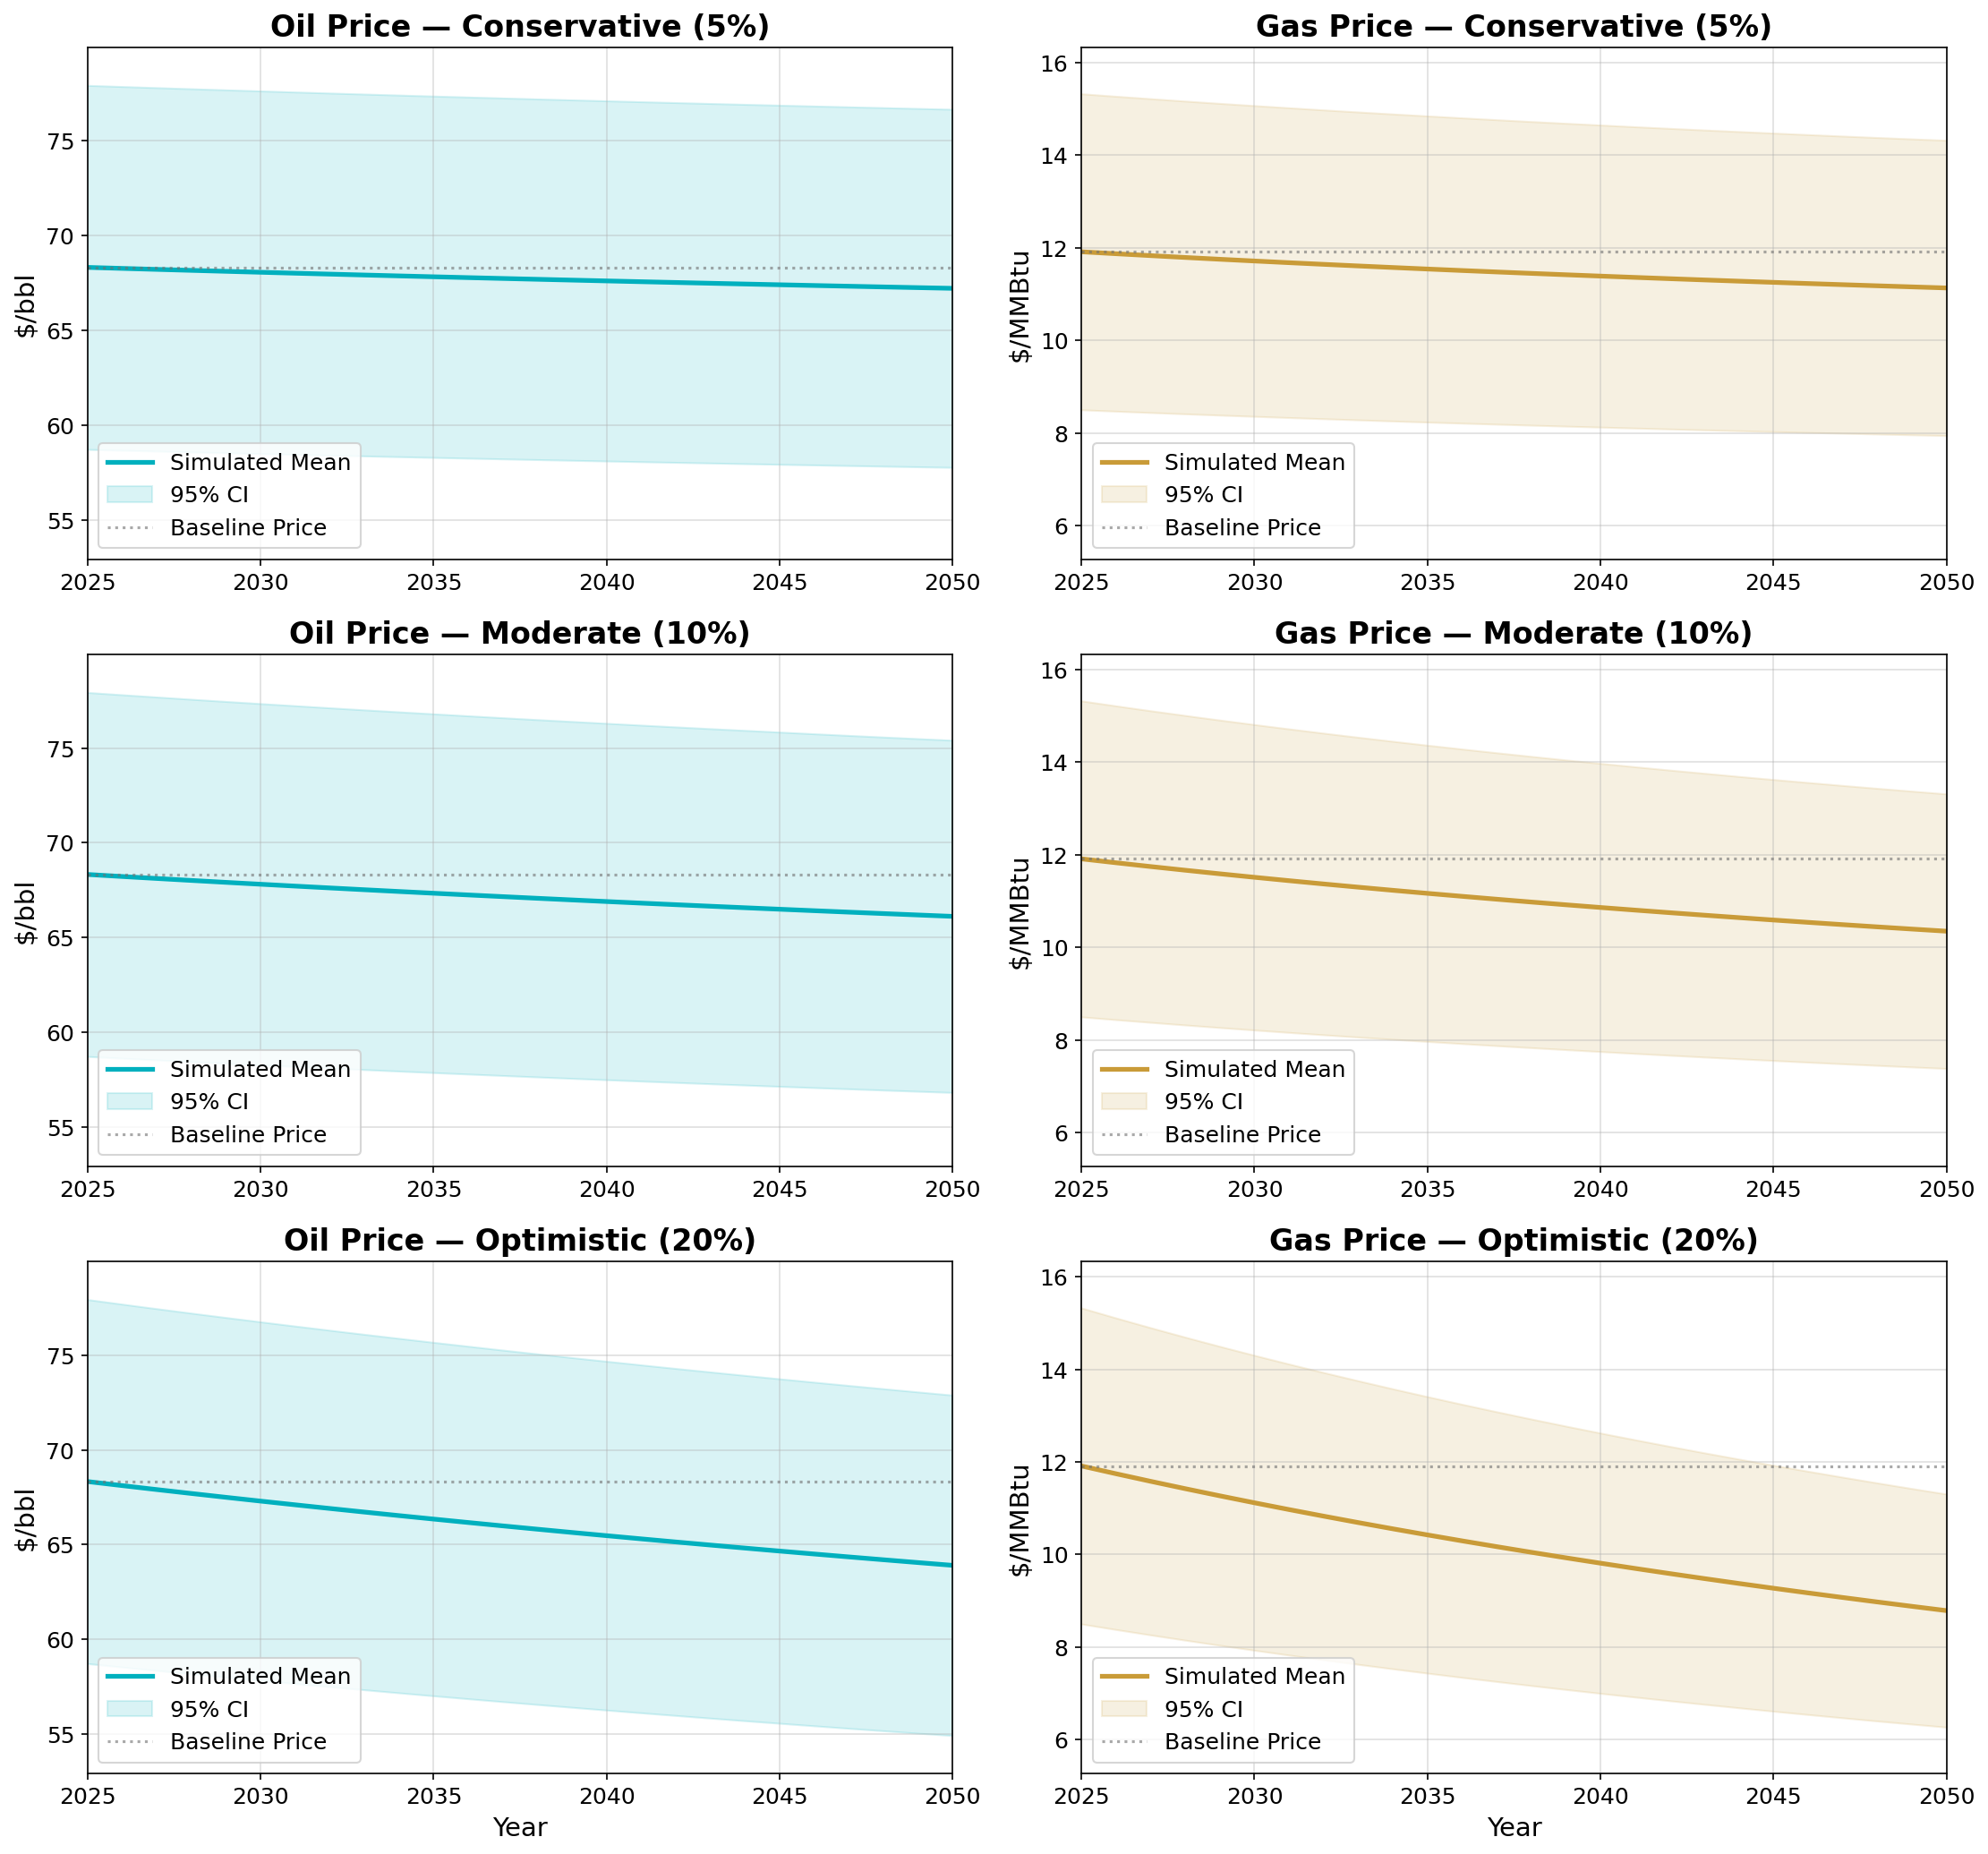

In [29]:
# Price Depression - All Scenarios
Es, Ed = 0.20, -0.30
elasticity = Ed - Es
z = stats.norm.ppf(0.975)
oil_moe = z * oil_std
gas_moe = z * gas_std
idx = fc_w_oil_p.index

# Use the exact same ticks as the supply graph
x_ticks = np.arange(2025, 2051, 5)

# Pre-compute all values to find global y-limits
all_oil_vals, all_gas_vals = [], []
results = []

for label, data in arctic_additions.items():
    oil_add = data['oil'].values
    gas_add = data['gas'].values
    
    pct_dP_oil = (oil_add / fc_w_oil_p.values) / elasticity
    pct_dP_gas = (gas_add / fc_w_gas_p.values) / elasticity

    m_oil = baseline_oil_price * (1 + pct_dP_oil)
    u_oil = (baseline_oil_price + oil_moe) * (1 + pct_dP_oil)
    l_oil = (baseline_oil_price - oil_moe) * (1 + pct_dP_oil)
    m_gas = baseline_gas_price * (1 + pct_dP_gas)
    u_gas = (baseline_gas_price + gas_moe) * (1 + pct_dP_gas)
    l_gas = (baseline_gas_price - gas_moe) * (1 + pct_dP_gas)

    all_oil_vals.extend([l_oil.min(), u_oil.max()])
    all_gas_vals.extend([l_gas.min(), u_gas.max()])
    results.append((label, m_oil, u_oil, l_oil, m_gas, u_gas, l_gas))

oil_ylim = (min(all_oil_vals) - 2, max(all_oil_vals) + 2)
gas_ylim = (min(all_gas_vals) - 1, max(all_gas_vals) + 1)

fig, axes = plt.subplots(3, 2, figsize=(15, 14))

for i, (label, m_oil, u_oil, l_oil, m_gas, u_gas, l_gas) in enumerate(results):
    ax_oil = axes[i, 0]
    ax_oil.plot(idx, m_oil, color=C_MEDTEAL, linewidth=2.5, label='Simulated Mean')
    ax_oil.fill_between(idx, l_oil, u_oil, color=C_MEDTEAL, alpha=0.15, label='95% CI')
    ax_oil.axhline(baseline_oil_price, color=C_BASELINE, linestyle=':', linewidth=1.5, alpha=0.6, label='Baseline Price')
    ax_oil.set_title(f'Oil Price — {label}', fontweight='bold')
    ax_oil.set_ylabel('$/bbl')
    ax_oil.set_ylim(oil_ylim)
    
    # 3. Apply the 2025 visual start and custom ticks
    ax_oil.set_xlim(2025, 2050)
    ax_oil.set_xticks(x_ticks)
    
    ax_oil.legend(loc='lower left')
    ax_oil.grid(alpha=0.4, linestyle='-')

    ax_gas = axes[i, 1]
    ax_gas.plot(idx, m_gas, color=C_MEDBROWN, linewidth=2.5, label='Simulated Mean')
    ax_gas.fill_between(idx, l_gas, u_gas, color=C_MEDBROWN, alpha=0.15, label='95% CI')
    ax_gas.axhline(baseline_gas_price, color=C_BASELINE, linestyle=':', linewidth=1.5, alpha=0.6, label='Baseline Price')
    ax_gas.set_title(f'Gas Price — {label}', fontweight='bold')
    ax_gas.set_ylabel('$/MMBtu')
    ax_gas.set_ylim(gas_ylim)
    
    # 3. Apply the 2025 visual start and custom ticks
    ax_gas.set_xlim(2025, 2050)
    ax_gas.set_xticks(x_ticks)
    
    ax_gas.legend(loc='lower left')
    ax_gas.grid(alpha=0.4, linestyle='-')

    if i == 2:
        ax_oil.set_xlabel('Year')
        ax_gas.set_xlabel('Year')

plt.tight_layout()
plt.savefig('./report/Figures/price_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print("\n" + "=" * 80)
print("Simulated Prices at Key Years (Mean Baseline)")
print("=" * 80)
price_rows = []
for label, data in arctic_additions.items():
    oil_add = data['oil']
    gas_add = data['gas']
    
    pct_dP_oil = (oil_add / fc_w_oil_p) / elasticity
    pct_dP_gas = (gas_add / fc_w_gas_p) / elasticity
    
    # UPDATED: Changed minus to plus to match the new elasticity math
    m_oil = baseline_oil_price * (1 + pct_dP_oil)
    m_gas = baseline_gas_price * (1 + pct_dP_gas)
    
    price_rows.append({
        'Scenario': label, 'Commodity': 'Oil ($/bbl)',
        'Baseline': f"${baseline_oil_price:.2f}",
        '2030': f"${m_oil.loc[2030]:.2f}", 
        '2040': f"${m_oil.loc[2040]:.2f}", 
        '2050': f"${m_oil.loc[2050]:.2f}",
        'Drop by 2050': f"{pct_dP_oil.loc[2050]*100:.2f}%"
    })
    price_rows.append({
        'Scenario': '', 'Commodity': 'Gas ($/MMBtu)',
        'Baseline': f"${baseline_gas_price:.2f}",
        '2030': f"${m_gas.loc[2030]:.2f}", 
        '2040': f"${m_gas.loc[2040]:.2f}", 
        '2050': f"${m_gas.loc[2050]:.2f}",
        'Drop by 2050': f"{pct_dP_gas.loc[2050]*100:.2f}%"
    })

print(pd.DataFrame(price_rows).to_string(index=False))


Simulated Prices at Key Years (Mean Baseline)
         Scenario     Commodity Baseline   2030   2040   2050 Drop by 2050
Conservative (5%)   Oil ($/bbl)   $68.32 $68.07 $67.61 $67.22       -1.62%
                  Gas ($/MMBtu)   $11.91 $11.71 $11.39 $11.13       -6.56%
   Moderate (10%)   Oil ($/bbl)   $68.32 $67.81 $66.90 $66.11       -3.24%
                  Gas ($/MMBtu)   $11.91 $11.51 $10.86 $10.35      -13.12%
 Optimistic (20%)   Oil ($/bbl)   $68.32 $67.29 $65.47 $63.90       -6.47%
                  Gas ($/MMBtu)   $11.91 $11.12  $9.81  $8.79      -26.23%


## 9. Macroeconomic Savings Table (All Scenarios)

In [ ]:
t_oil_bbl = fc_t_oil_c * 1_000_000
t_gas_mmbtu = fc_t_gas_c * 1_037_000  # BCF → MMBtu

rows = []

# Loop over the pre-calculated dictionary to avoid array size crashes and use correct rates
for label, data in arctic_additions.items():
    oil_add = data['oil']
    gas_add = data['gas']
    
    # Calculate price drop percentages natively in Pandas
    dP_oil = (oil_add / fc_w_oil_p) / elasticity
    dP_gas = (gas_add / fc_w_gas_p) / elasticity

    for price_label, bp_oil, bp_gas in [
        ('Lower',  baseline_oil_price - oil_moe, baseline_gas_price - gas_moe),
        ('Mean',   baseline_oil_price,           baseline_gas_price),
        ('Upper',  baseline_oil_price + oil_moe, baseline_gas_price + gas_moe),
    ]:
        sim_oil = bp_oil * (1 + dP_oil)
        sim_gas = bp_gas * (1 + dP_gas)
        
        # Because these are all Pandas Series, this math perfectly maps year-by-year
        oil_sav = t_oil_bbl * (bp_oil - sim_oil)
        gas_sav = t_gas_mmbtu * (bp_gas - sim_gas)

        for commodity, sav in [('Oil', oil_sav), ('Gas', gas_sav), ('Total', oil_sav + gas_sav)]:
            rows.append({
                'Scenario': label,
                'Price': price_label,
                'Commodity': commodity,
                'By 2030': round(sav.loc[:2030].sum() / 1e9, 2),
                'By 2040': round(sav.loc[:2040].sum() / 1e9, 2),
                'By 2050': round(sav.sum() / 1e9, 2),
            })

df_savings = pd.DataFrame(rows)

# Show mean baseline (the main table)
df_mean = df_savings[df_savings['Price'] == 'Mean'].drop(columns='Price')
print("=== MEAN BASELINE SAVINGS (Billion $) ===\n")
print(df_mean.to_string(index=False))

=== MEAN BASELINE SAVINGS (Billion $) ===

         Scenario Commodity  By 2030  By 2040  By 2050
Conservative (5%)       Oil     0.32     2.62     7.35
Conservative (5%)       Gas     1.23    10.25    28.69
Conservative (5%)     Total     1.54    12.87    36.04
   Moderate (10%)       Oil     0.63     5.25    14.70
   Moderate (10%)       Gas     2.46    20.49    57.39
   Moderate (10%)     Total     3.09    25.74    72.09
 Optimistic (20%)       Oil     1.26    10.49    29.40
 Optimistic (20%)       Gas     4.91    40.98   114.77
 Optimistic (20%)     Total     6.17    51.48   144.17


In [32]:
# Show full table for reference
print("\n\n=== ALL PRICE SCENARIOS ===\n")
print(df_savings.to_string(index=False))



=== ALL PRICE SCENARIOS ===

         Scenario Price Commodity  By 2030  By 2040  By 2050
Conservative (5%) Lower       Oil     0.27     2.25     6.32
Conservative (5%) Lower       Gas     0.88     7.31    20.47
Conservative (5%) Lower     Total     1.15     9.56    26.79
Conservative (5%)  Mean       Oil     0.32     2.62     7.35
Conservative (5%)  Mean       Gas     1.23    10.25    28.69
Conservative (5%)  Mean     Total     1.54    12.87    36.04
Conservative (5%) Upper       Oil     0.36     2.99     8.38
Conservative (5%) Upper       Gas     1.58    13.18    36.92
Conservative (5%) Upper     Total     1.94    16.17    45.30
   Moderate (10%) Lower       Oil     0.54     4.51    12.63
   Moderate (10%) Lower       Gas     1.75    14.62    40.94
   Moderate (10%) Lower     Total     2.29    19.13    53.57
   Moderate (10%)  Mean       Oil     0.63     5.25    14.70
   Moderate (10%)  Mean       Gas     2.46    20.49    57.39
   Moderate (10%)  Mean     Total     3.09    25.74   